<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/N100back2begining4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

Nx, Ny = 200, 200
dt = 0.01
steps = 2000

alpha_base = 0.6
beta       = 0.005
gamma      = 0.0001

def N_resonance_factor(N, N_res=100, sigma=3.0):
    return np.exp(-((N - N_res)**2) / (2.0 * sigma**2))

def laplacian(S):
    return (
        np.roll(S, 1, axis=0) + np.roll(S, -1, axis=0) +
        np.roll(S, 1, axis=1) + np.roll(S, -1, axis=1) -
        4 * S
    )

def action_quantum(N=100):
    alpha = alpha_base * N_resonance_factor(N)
    S = np.random.uniform(-1, 1, (Nx, Ny))

    S[60:90, 60:90] += 0.5
    S[120:150, 120:150] -= 0.5

    action_per_step = []

    for step in range(steps):
        lap = laplacian(S)
        global_mean = np.mean(S)

        dSdt = alpha * lap - beta * S - gamma * global_mean
        S += dt * dSdt

        # instantaneous curvature-action
        A_t = np.sum(np.abs(lap))
        action_per_step.append(A_t)

    return np.array(action_per_step)


In [ ]:
A = action_quantum(100)
print("Mean action quantum:", np.mean(A[500:]))   # ignore early transient
print("Std:", np.std(A[500:]))


Mean action quantum: 169.2436062068807
Std: 109.64535541802424


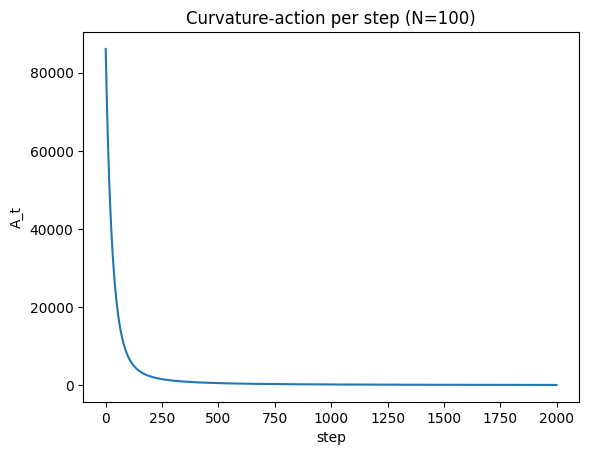

In [ ]:
import matplotlib.pyplot as plt

A = action_quantum(100)
plt.plot(A)
plt.title("Curvature-action per step (N=100)")
plt.xlabel("step")
plt.ylabel("A_t")
plt.show()


In [ ]:
late = A[-1000:]
print("Late mean:", np.mean(late))
print("Late std:", np.std(late))


Late mean: 110.4741863367491
Late std: 32.737967251288964


In [ ]:
def late_action_mean(N):
    A = action_quantum(N)
    late = A[-1000:]
    return np.mean(late), np.std(late)

Ns = [95, 99, 100, 101, 105]
stats = [(N, *late_action_mean(N)) for N in Ns]
print(stats)


[(95, np.float64(813.1493910018357), np.float64(270.2667676509647)), (99, np.float64(117.80497582913564), np.float64(35.27802039849809)), (100, np.float64(106.86400104440965), np.float64(32.38040690445237)), (101, np.float64(115.06759638304665), np.float64(34.94802917409854)), (105, np.float64(828.6218685722918), np.float64(270.55082371019745))]
